# Set

In [ ]:
# !pip install yt-dlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 8.1 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# !pip install torch torchvision
# !pip install git+https://github.com/openai/CLIP.git
# !pip install opencv-python pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 27.2 MB/s  0:00:01m0:00:0100:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import os
import cv2
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# Code

In [8]:
model, preproccess = clip.load('ViT-B/32', device='cuda' if torch.cuda.is_available() else 'cpu')

100%|███████████████████████████████████████| 338M/338M [03:46<00:00, 1.56MiB/s]


In [11]:
video_path = '/Users/nikitasudarikov/Documents/Учеба/video-moment-retrieval/data/IMG_4857.MOV'
assert os.path.exists(video_path), f"Video file not found: {video_path}"

In [ ]:
# Достаём по одному кадру в секунду
def extract_frames(video_path, sample_every_sec=1):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Не удалось открыть видео: {video_path}"
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames / fps if fps > 0 else 0

    print(f"FPS: {fps:.2f}")
    print(f"Total frames: {total_frames}")
    print(f"Duration (sec): {duration_sec:.2f}")

    frame_interval = max(1, int(round(fps * sample_every_sec)))
    
    frames = []
    timestamps = []
    frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_id % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame_rgb))
            timestamps.append(frame_id / fps)
        
        frame_id += 1

    cap.release()
    return frames, timestamps

frames, timestamps = extract_frames(video_path, sample_every_sec=1)
print("num sampled frames:", len(frames))

FPS: 29.82
Total frames: 2065
Duration (sec): 69.26
num sampled frames: 69


In [16]:
def show_frames(frames, timestamps, max_show=6):
    n = min(len(frames), max_show)
    plt.figure(figsize=(15, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(frames[i])
        plt.title(f"{timestamps[i]:.1f}s")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


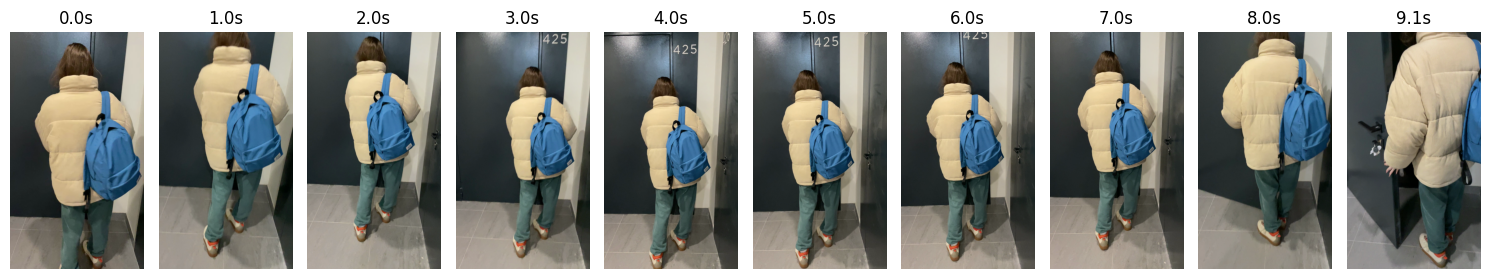

In [20]:
show_frames(frames, timestamps, max_show=10)

In [33]:
image_inputs = torch.stack([preproccess(frame) for frame in frames])

with torch.no_grad():
    image_features = model.encode_image(image_inputs)

In [35]:
image_features = image_features / image_features.norm(dim=-1, keepdim=True)

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [41]:
text_query = 'a dog'
text_tokens = clip.tokenize([text_query]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

In [ ]:
similarity = (image_features @ text_features.T).squeeze().cpu().numpy()

In [44]:
similarity

array([0.23666336, 0.23505044, 0.22957546, 0.23147768, 0.21884644,
       0.22425461, 0.23130475, 0.23837438, 0.22981375, 0.23692709,
       0.23188785, 0.23538214, 0.2539626 , 0.24701217, 0.24754648,
       0.23557967, 0.2598354 , 0.26480728, 0.24302223, 0.24998839,
       0.25956398, 0.26300222, 0.27003542, 0.26451054, 0.23676424,
       0.24880044, 0.2688541 , 0.25548303, 0.26907614, 0.24806923,
       0.26051453, 0.2528118 , 0.26185095, 0.26711655, 0.25727463,
       0.26671192, 0.26068753, 0.25128326, 0.25479957, 0.25296542,
       0.24969774, 0.24743086, 0.23774762, 0.2308887 , 0.23240615,
       0.22689396, 0.23401976, 0.25769934, 0.26609132, 0.25597036,
       0.26095465, 0.23224878, 0.23706742, 0.25567186, 0.23237035,
       0.24601759, 0.23627263, 0.24775346, 0.23412788, 0.23249799,
       0.24404916, 0.21547033, 0.22874418, 0.2355876 , 0.24220046,
       0.24086502, 0.23573685, 0.24067572, 0.27032346], dtype=float32)